In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snb

## 1. Bernoulli Neuron: Fisher information and estimator ##

Assume a Bernoulli neuron with arbitrary tuning curve $f(s)$, i.e.
$$p(r| f(s)) = f(s)^r(1- f(s))^{1-r}, \qquad r \in \{0; 1\}$$

*Note: $r$ is discrete and $s$ is continuous.*

**(a)** Compute the Fisher information $J_s$. *(2 points)*

We use the result from the lecture on how $J_s$ depends on the Fisher information $J_f$ of the Bernoulli parameter $f$
\begin{split}
    J_s &= \left[\frac{\partial f(s)}{\partial s} \right]^2 \cdot J_f 
\end{split}
Where
\begin{split}
    J_f &= Var\left(\frac{\partial}{\partial s} \log p\left(r | f(s)\right)\right) \\
    &= - E_r\left[\left(\frac{\partial^2}{\partial f^2} \log p(r | f) \right) | f \right] \text{ (c.f. lecture)} \\
    &= - E_r\left[\left(\frac{\partial^2}{\partial f^2} \log\left(f^r (1- f)^{1-r}\right) \right) | f \right] \\
    &= - E_r\left[\frac{\partial^2}{\partial f^2} \left(r \log f + (1-r) \log(1-f) \right) | f \right] \\
    &= - E_r\left[\frac{\partial}{\partial f} \left(\frac{r}{f} - \frac{1-r}{1-f} \right) | f \right] \\
    &= - E_r\left[- \frac{r}{f^2} - \frac{1-r}{(1-f)^2} | f \right] \\
    &= \frac{E_r\left[r | f \right]}{f^2} + \frac{1-E_r\left[r | f \right]}{(1-f)^2} \\
    &= \frac{1}{f} + \frac{1}{(1-f)} \text{ (since $E_r[r | f] = f$)} \\
    &= \frac{1}{f (1-f)}
\end{split}
Therefore 
\begin{split}
    J_s &= \frac{\left[\frac{\partial f(s)}{\partial s} \right]^2}{f(s) (1-f(s))} 
\end{split}

**(b)** Assume $f(s) = \frac{1}{1+s^2}$. Plot the Fisher information on the interval $s\in[-5, 5]$. Additionally, plot the Fisher information for a Poisson neuron with the same tuning curve using the formula from the lecture. *(2 points)*

If $f(s) = \frac{1}{1+s^2}$ then 
\begin{split}
    \left[\frac{\partial f(s)}{\partial s} \right]^2 = \left[- \frac{2s}{(1+s^2)^2} \right]^2 = \frac{4s^2}{(1+s^2)^4}
\end{split}
Thus for the Bernoulli neuron
\begin{split}
    J_s^B &= \frac{\frac{4s^2}{(1+s^2)^4}}{\frac{1}{1+s^2} (1-\frac{1}{1+s^2})} \\
    &= \frac{\frac{4s^2}{(1+s^2)^2}}{(1+s^2)-1} \\
    &= \frac{4}{(1+s^2)^2} \\
\end{split}
and for the Poisson neuron with $J_f^P = \frac{1}{f(s)} = 1+s^2$
\begin{split}
    J_s^P &= \frac{4s^2}{(1+s^2)^4} \cdot (1+s^2) = \frac{4s^2}{(1+s^2)^3} \\
\end{split}

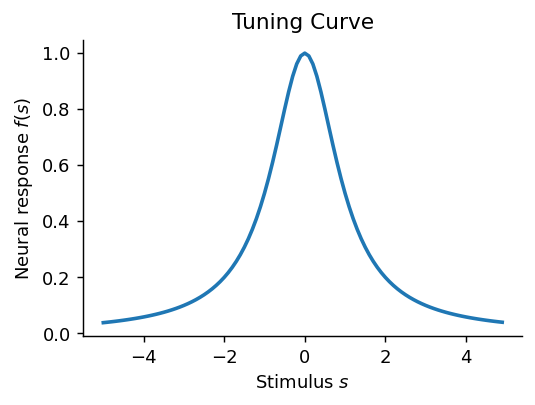

In [ ]:
def tuning_curve(s):
    return 1 / (1 + s**2)

s = np.arange(-5, 5, 0.1)

fig = plt.figure(dpi=130, figsize=(4, 3), constrained_layout = True)
plt.title("Tuning Curve")
plt.plot(s, tuning_curve(s), lw = 2)
plt.xlabel("Stimulus $s$")
plt.ylabel("Neural response $f(s)$")
snb.despine()

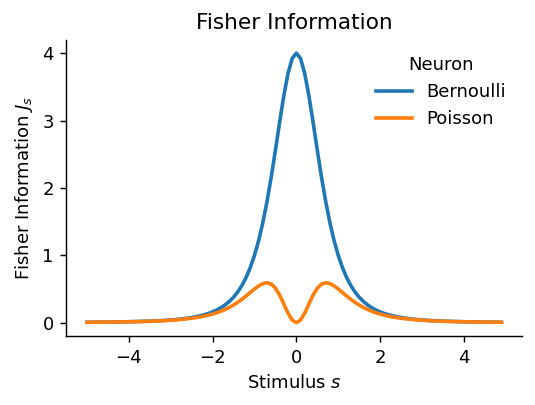

In [18]:
def J_bernoulli(s):
    return 4 / (1 + s**2)**2

def J_poisson(s):
    return 4 * s**2 / (1+s**2)**3

s = np.arange(-5, 5, 0.1)

fig = plt.figure(dpi=130, figsize=(4, 3), constrained_layout = True)
plt.title("Fisher Information")
plt.plot(s, J_bernoulli(s), label = "Bernoulli", lw = 2)
plt.plot(s, J_poisson(s), label = "Poisson", lw = 2)
plt.xlabel("Stimulus $s$")
plt.ylabel("Fisher Information $J_s$")
plt.legend(frameon=False, title="Neuron")
snb.despine()

WHY?

**(c)** Given an estimator
$\hat s(r) = \begin{cases} 1 & if\qquad r=0\\ 0 &if\qquad r=1\end{cases}$.\
Compute variance $\sigma^2(s)$, bias $b(s)$, and mean squared error $MS(s)$ of this estimator. Don't use the relationship $MS(s) = b^2(s) + \sigma^2(s)$, but instead compute them independently. *(2 points)*

*Confirm for yourself with an automatized tool like wolphramalpha that their relationship is correct.*

The definition implies 
\begin{split}
    \hat s(r) = 1 - r \sim f(s)^{1 - \hat s}(1- f(s))^{\hat s} = \text{Bernoulli}(\hat s | 1-f(s))
\end{split}
Then
\begin{split}
    \sigma_{\hat s}^2(s) &= f(s) (1-f(s)) \\
    &= \frac{1}{1 + s^2} (1 - \frac{1}{1 + s^2}) \\
    &= \frac{1}{1 + s^2} \frac{s^2}{1 + s^2} \\
    &= \left( \frac{s}{1 + s^2} \right)^2 \\
\end{split}
Furthermore
\begin{split}
    b(s) &= E_{\hat s}\left[\hat s | s \right] - s \\
    &= 1 - f(s) - s \\
    &= \frac{s^2}{1 + s^2} - s \\
    &= s \left(\frac{s}{1 + s^2} - 1\right) \\
\end{split}
And
\begin{split}
    MS(s) &= E_{\hat s}\left[(s - \hat s)^2 | s \right] \\
    &= \sum_{\hat s = 0}^1 (s - \hat s)^2 p(\hat s | s) \\
    &= \sum_{\hat s = 0}^1 (s - \hat s)^2 f(s)^{1 - \hat s}(1- f(s))^{\hat s} \\
    &= s^2 f(s) + (s - 1)^2 (1 - f(s)) \\
    &= \frac{s^2}{1 + s^2} + (1 - s)^2 \frac{s^2}{1 + s^2} \\
    &= \frac{s^2}{1 + s^2} \left[1 + (1 - s)^2\right] \\
\end{split}

Why is all fo this so ugly? And how to interpret this..?

**(d)** Assume $s\sim\mathcal{U}([0,1])$. Compute the ideal observer $\hat s_{MS}(r)$. *(2 points)*

*Hint: Compute $p(r=0)$ and $p(r=1)$ with law of total probability. Then use Bayes' theorem to compute $p(s|r)$. Useful integrals:*
\begin{split}
\int \frac1{1+s^2} ds &= \tan^{-1}(s) + c, \qquad c\in\mathbb{R}\\
\int \frac{s}{1+s^2} ds &= \frac12 \ln(1+s^2) + c, \qquad c\in\mathbb{R} \\
\int \frac{s^2}{1+s^2} ds &= s - \tan^{-1}(s) + c, \qquad c\in\mathbb{R} \\
\int \frac{s^3}{1+s^2} ds &= \frac{s^2 - \ln(1+s^2)}{2} + c, \qquad c\in\mathbb{R}
\end{split}

**(e*)** Contextualize the previous exercises with Cramer-Rao bound. *(2 points)*


## 2: Minimum Discrimination Error (MDE)

Given two stimuli $s_1$ and $s_2$ with probabilities $\lambda$ and $1-\lambda$, the response function is given as

$$p(r|s) = \begin{cases}
\tfrac12 &for & s=0 &and &r\in[-1,1]\\
\tfrac1{2x} &for &s=1 &and &r\in[-x, x]\\
0 &else
\end{cases}$$

**(a)** Draw diagrams for each possible case and highlight the MDE. Additionally, write down the decision for the Maximal a posteriori estimator $\hat{s}_{MAP}(r)$. *(2 points)*\
*Hint: Differentiate the cases by $\lambda$ and $x$. (there are 4 possibilities)*

**(b)** Compute the MDE for each case analytically. *(1 point)*

**(c)** Confirm your results by simulation for multiple sets of parameters $\lambda$ and $x$.
Choose your selection of parameters such that they cover all cases from (a). *(2 points)*
1. Generate stimuli (sufficient amount)
2. Generate responses
3. Apply estimator (write a function of $\hat{s}_{MAP}(r)$ from (a))
4. Compute MDE
5. Compare to analytical MDE